# Лекція 3-4. Нейронні мережі.

## 0. Налаштування середовища

### 0.0. Імпортуємо бібліотеки

In [1]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"


Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості. 
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) — 
тут це не критично, адже дані й модель дрібні.

In [2]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed зафіксовано:", SEED)


Seed зафіксовано: 42


### 0.3. Використовуємо графічний прискорювач, якщо доступний.
На Colab зазвичай є безкоштовний GPU (T4). 
Використовуємо його, якщо він доступний.
Якщо ні, залишаємося на CPU.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Використовуємо:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Використовуємо: cpu


### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [3]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lecture3"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lecture3


---
## 1. Робота з "реальною" задачею

На попередній лекції ми вирішували штучну задачу.
Наші дані мали лише один параметр (`TikToks per Day → IQ`), 
дані були чисті (без аутлайєрів)
і мали чітку лінійну кореляцію з вихідними даними.
У реальних задачах ознак завжди більше, не мають чіткої кореляції та містять аутлайєри.

### 1.0. Датасет California Housing

**Проблема.** На ціну будинку впливає безліч факторів (локація, розмір, стан, час), а сам ринок нерухомості волатильний і залежить від попиту/пропозиції та економіки (ставки, інфляція). Датасети зазвичай містять обмежений набір ознак, тому точний прогноз ціни — складна задача, де важливий feature engineering.

**Мета.** Побудувати модель, що передбачає `MedHouseVal` (медіанну ціну будинку); навчитися заповнювати пропуски даних найпростішим unsupervised-методом, знаходити аутлайєри та використовувати ці дані для тренування власної моделі. Мета — не ідеальна модель, а розуміння підходу.

### 1.1. Завантажуємо реальні дані з Hugging Face Hub

Зазвичай, потрібний датасет можна знайти на [Kaggle](https://www.kaggle.com/) або [HuggingFace](https://huggingface.co).

Завантажимо датасет [California Housing](https://huggingface.co/datasets/gvlassis/california_housing) з HuggingFace.

Зверніть увагу, що інколи датасет має значний розмір, тому Colab може попросити використати API креденшиали з Вашого облікового запису відповідного сервісу з датасетами.

In [4]:
# install and import [datasets](https://huggingface.co/docs/datasets/en/index) library

!pip install -q datasets
from datasets import load_dataset

In [5]:
# load California Housing dataset from HuggingFace datasets

# NOTE: if the dataset is large, consider loading the dataset 
# in streaming mode (`streaming=True`) to avoid downloading 
# the entire dataset at once, to not exceed the Colab disk space and RAM limit.

HF_REPO_ID = "fantkolja/california-housing-with-missing-data"

# usually datasets are already split into train, validation, and test sets on HF, but it's a dataset for learning purposes.
housing_dataset = load_dataset(HF_REPO_ID)

print(housing_dataset)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/588 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  806kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20640 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 20640
    })
})


### 1.2. Перетворюємо на DataFrame

`datasets` повертає `DatasetDict` зі спліт-таблицями, а не `pandas.DataFrame`. Конвертуємо кожен спліт і об'єднуємо в одну таблицю — так зручніше робити первинний огляд даних.

In [6]:
# convert HuggingFace datasets to pandas DataFrames

housing_df = housing_dataset["train"].to_pandas()

print("\nЗагальний розмір таблиці:", housing_df.shape)


Загальний розмір таблиці: (20640, 9)


### h_1. Хто відкриє цю клітинку, отримає незарах!

#### h_1.1. Додаємо пропуски (для навчальних цілей)

Реальний датасет California Housing пропусків не містить (див. `info()` вище) — а нам вони потрібні, щоб на практиці відпрацювати техніки імпутації з лекції.

Штучно вносимо пропуски в **до 10% рядків**: для кожного обраного рядка випадково обираємо одну ознаку (окрім таргету `MedHouseVal`) і замінюємо її значення на `NaN`. Оригінальний `housing_df` лишаємо незмінним для порівняння, працюємо далі з копією `housing_df_missing`.

In [21]:
MISSING_FRACTION = 0.10

feature_cols = [c for c in housing_df.columns if c != "MedHouseVal"]

rng = np.random.default_rng(SEED)
n_missing_rows = int(len(housing_df) * MISSING_FRACTION)
missing_rows = rng.choice(housing_df.index, size=n_missing_rows, replace=False)

housing_df_missing = housing_df.copy()
for row in missing_rows:
    col = rng.choice(feature_cols)
    housing_df_missing.loc[row, col] = np.nan

print(f"Рядків із пропуском: {housing_df_missing.isna().any(axis=1).sum()} з {len(housing_df_missing)}")
housing_df_missing.isna().sum()

Рядків із пропуском: 2064 з 20640


,0
MedInc,241
HouseAge,297
AveRooms,248
AveBedrms,267
Population,249
AveOccup,240
Latitude,263
Longitude,259
MedHouseVal,0


#### h_1.2 Зберігаємо датасет із пропусками

Зберігаємо `housing_df_missing` у форматі бібліотеки `datasets` (`save_to_disk`) в `ARTIFACT_DIR` — це той самий формат, що й після `load_dataset`, тому пізніше його можна просто завантажити назад через `load_from_disk` і викликати `.push_to_hub("ваш-логін/назва-датасету")`, щоб опублікувати на Hugging Face.

In [ ]:
from datasets import Dataset

housing_missing_dataset = Dataset.from_pandas(housing_df_missing, preserve_index=False)

housing_missing_dir = os.path.join(ARTIFACT_DIR, "california_housing_missing")
housing_missing_dataset.save_to_disk(housing_missing_dir)

print("Датасет із пропусками збережено в:", housing_missing_dir)
print(housing_missing_dataset)

#### h_1.3. Публікуємо на Hugging Face Hub

Логінимось у Hugging Face (якщо запитає токен — створити можна в [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) з правом **Write**), тоді завантажуємо збережений датасет із диска і публікуємо його під `fantkolja/california-housing-with-missing-data`.

In [ ]:
from huggingface_hub import notebook_login
from datasets import load_from_disk

notebook_login()

housing_missing_dataset = load_from_disk(housing_missing_dir)
housing_missing_dataset.push_to_hub(HF_REPO_ID)

print(f"Опубліковано: https://huggingface.co/datasets/{HF_REPO_ID}")

### 1.3. Спліт даних

Розділяємо дані на **train**, **val** і **test** одразу після завантаження — ще до EDA та обробки пропусків. Якщо зробити спліт пізніше, статистики (медіана, кореляції, аутлайєри), пораховані на всьому датасеті, непомітно "просочать" інформацію з val/test у процес аналізу — а це data leakage.

In [14]:
from sklearn.model_selection import train_test_split

# Спліт робимо одразу після завантаження — до EDA та обробки пропусків,
# щоб уникнути data leakage: жодна статистика з val/test не повинна впливати
# на рішення під час аналізу та препроцесингу.

# Спочатку відокремлюємо train (60%) від решти (40%),
# потім решту порівну ділимо на val і test (по 20% від усього датасету).
train_df, temp_df = train_test_split(housing_df, test_size=0.4, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"Розмір навчальної вибірки (train): {train_df.shape}")
print(f"Розмір валідаційної вибірки (val): {val_df.shape}")
print(f"Розмір тестової вибірки (test): {test_df.shape}")

Розмір навчальної вибірки (train): (12384, 9)
Розмір валідаційної вибірки (val): (4128, 9)
Розмір тестової вибірки (test): (4128, 9)


### 1.4. Загальний огляд даних

Перше, що варто зробити з новим датасетом — швидко оглянути його: `head()` (як виглядають дані), `info()` (типи колонок, пропуски) та `describe()` (базова статистика). Робимо це тільки на `train_df` — val і test уже відкладені і не чіпаємо.

In [15]:
# Check the first few rows of the dataset to get an overview
# of the data structure and the features available for analysis.

train_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
9012,5.8735,35.0,5.811639,1.056662,1521.0,2.329250,34.11,-118.63,4.48100
2769,1.4688,8.0,10.000000,1.916667,63.0,2.625000,33.32,-115.98,0.53800
1953,2.1603,28.0,4.808173,0.995460,2008.0,2.279228,38.74,-120.78,1.11300
16897,4.7404,43.0,5.855140,1.009346,967.0,2.259346,37.58,-122.37,5.00001
17866,3.2617,10.0,3.929142,1.051896,2032.0,2.027944,37.45,-121.92,2.52200


In [16]:
# Check the data types and non-null counts of each column to understand the dataset's structure and identify any missing values.

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12384 entries, 9012 to 15795
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       12221 non-null  float64
 1   HouseAge     12200 non-null  float64
 2   AveRooms     12248 non-null  float64
 3   AveBedrms    12228 non-null  float64
 4   Population   12248 non-null  float64
 5   AveOccup     12236 non-null  float64
 6   Latitude     12232 non-null  float64
 7   Longitude    12218 non-null  float64
 8   MedHouseVal  12384 non-null  float64
dtypes: float64(9)
memory usage: 967.5 KB


In [17]:
# Get a summary of the dataset's statistics.

train_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,12221.000000,12200.000000,12248.000000,12228.000000,12248.000000,12236.000000,12232.000000,12218.000000,12384.000000
mean,3.869644,28.574754,5.433401,1.096752,1429.436643,3.137460,35.660579,-119.591253,2.063397
std,1.894801,12.571813,2.462686,0.442393,1127.840190,13.282705,2.138860,2.008156,1.151877
min,0.499900,1.000000,0.888889,0.375000,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.567000,18.000000,4.453849,1.006783,793.750000,2.434912,33.940000,-121.810000,1.196000
50%,3.531300,29.000000,5.234125,1.049180,1172.000000,2.824431,34.270000,-118.520000,1.788500
75%,4.756600,37.000000,6.060692,1.099716,1732.000000,3.279435,37.720000,-118.020000,2.636000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 1.5. Обробка пропусків

#### 1.5.1. Переглядаємо рядки з пропусками

In [18]:
train_df[train_df.isnull().any(axis=1)]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20559,4.7222,30.0,6.424691,0.990123,NaN,2.422222,38.67,-121.79,1.672
702,3.8958,6.0,4.267016,1.029668,1189.0,NaN,37.63,-122.02,3.011
6746,4.2434,NaN,5.315457,1.075710,757.0,2.388013,34.12,-118.08,2.705
20444,5.5925,13.0,5.757981,1.043254,NaN,3.283213,34.30,-118.90,2.086
16095,3.8333,48.0,5.234201,1.096654,NaN,3.312268,37.76,-122.50,2.963
...,...,...,...,...,...,...,...,...,...
14502,5.4170,11.0,4.925868,NaN,1223.0,1.929022,32.87,-117.23,1.968
1899,NaN,24.0,5.939502,1.501779,589.0,2.096085,38.89,-120.01,1.008
19769,2.6250,27.0,NaN,1.080808,508.0,2.565657,39.82,-122.11,0.917
6420,3.6336,27.0,NaN,1.081376,2899.0,2.432047,34.14,-117.98,2.352


#### 1.5.2. Підхід перший: видалення (drop)
**Перевага**: технологічно просто.

**Недолік**: втрата гіпотетично цінної інформації.

**Порада**: спробуй видалити, але якщо модель недотреновується спробуй імпутацію (підхід другий)

In [19]:
# Drop rows with missing values to prepare the dataset for training a neural network model. 
# This is a simple approach to handle missing data, but it may not be the best strategy in all cases, 
# especially if a significant portion of the data is missing.

copy = train_df.dropna(inplace=False) # inplace=False to create a new DataFrame without modifying the original one.

print(f"Original dataset shape: {train_df.shape}")
print(f"\nDataset shape after dropping missing values: {copy.shape}\n")

copy.info()

assert train_df.shape[0] > copy.shape[0], "The number of rows in original dataset should be greater than the number of rows in the dataset after dropping missing values."

Original dataset shape: (12384, 9)

Dataset shape after dropping missing values: (11143, 9)

<class 'pandas.core.frame.DataFrame'>
Index: 11143 entries, 9012 to 15795
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       11143 non-null  float64
 1   HouseAge     11143 non-null  float64
 2   AveRooms     11143 non-null  float64
 3   AveBedrms    11143 non-null  float64
 4   Population   11143 non-null  float64
 5   AveOccup     11143 non-null  float64
 6   Latitude     11143 non-null  float64
 7   Longitude    11143 non-null  float64
 8   MedHouseVal  11143 non-null  float64
dtypes: float64(9)
memory usage: 870.5 KB


#### 1.5.3. Підхід другий: імпутація (imputation)
**Перевага**: рядки не втрачаємо — модель бачить усі спостереження, навіть там, де бракує одного значення.

**Недолік**: підставлене значення — це оцінка, а не реальне спостереження.

**Порада**: метод обирай залежно від типу колонки та від того, чи важливі зв'язки між ознаками — від простого середнього/медіани до методу, що враховує решту ознак (kNN).

##### 1.5.3.1. Прості методи — за типом колонки

Проходимось по колонках `train_df`, у яких є пропуски, і для кожної обираємо метод залежно від типу даних: для числових — **медіана** (стійкіша до викидів, ніж середнє), для категоріальних — **мода**. У нас лише числові дані.

Статистику (медіану/моду) рахуємо **тільки на train**, і тим самим значенням заповнюємо пропуски в train, val і test — так само, як зі стандартизацією, щоб уникнути data leakage.

In [20]:
# Simple imputation: pick a strategy per column based on its dtype
# (median for numeric columns, mode for categorical columns).
# Statistics (median/mode) are computed on train ONLY, then reused as-is
# on val and test — this avoids data leakage.

train_imputed_simple = train_df.copy()
val_imputed_simple = val_df.copy()
test_imputed_simple = test_df.copy()

numeric_cols = train_imputed_simple.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {list(numeric_cols)}\n")

# we actually don't have categorical columns here, but let's keep it for the sake of completeness
categorical_cols = train_imputed_simple.select_dtypes(exclude=[np.number]).columns
print(f"Categorical columns: {list(categorical_cols)}\n")

cols_with_nan = train_imputed_simple.columns[train_imputed_simple.isna().any()]
print(f"Columns with missing values: {len(cols_with_nan)}\n")

for col in cols_with_nan:
    if col in numeric_cols:
        fill_value = train_imputed_simple[col].median()  # рахуємо тільки на train
    else:
        fill_value = train_imputed_simple[col].mode()[0]

    train_imputed_simple[col] = train_imputed_simple[col].fillna(fill_value)
    val_imputed_simple[col] = val_imputed_simple[col].fillna(fill_value)    # те саме значення застосовуємо до val
    test_imputed_simple[col] = test_imputed_simple[col].fillna(fill_value)  # і до test

    print(f"{col}: заповнено значенням {fill_value:.4f}" if col in numeric_cols else f"{col}: заповнено значенням '{fill_value}'")

print("\nЗалишилось пропусків (train):", train_imputed_simple.isna().sum().sum())
print("Залишилось пропусків (val):", val_imputed_simple.isna().sum().sum())
print("Залишилось пропусків (test):", test_imputed_simple.isna().sum().sum())

Numeric columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Categorical columns: []

Columns with missing values: 8

MedInc: заповнено значенням 3.5313
HouseAge: заповнено значенням 29.0000
AveRooms: заповнено значенням 5.2341
AveBedrms: заповнено значенням 1.0492
Population: заповнено значенням 1172.0000
AveOccup: заповнено значенням 2.8244
Latitude: заповнено значенням 34.2700
Longitude: заповнено значенням -118.5200

Залишилось пропусків (train): 0
Залишилось пропусків (val): 0
Залишилось пропусків (test): 0


##### 1.5.3.2. Просунутий метод — kNN imputation

Проста імпутація ігнорує зв'язки між ознаками. kNN-імпутація натомість для кожної колонки з пропусками тренує окремий `KNeighborsRegressor`: рядки без пропусків стають train-множиною, а пропущене значення передбачається на основі решти ознак того ж рядка.

Щоб уникнути data leakage, моделі навчаємо **тільки на train** (`fit_knn_imputers`), а тоді застосовуємо ці самі навчені моделі до train, val і test (`apply_knn_imputers`) — так само, як і з медіаною/модою вище.

In [23]:
from sklearn.neighbors import KNeighborsRegressor

# Fit/transform-версія kNN-імпутації:
# fit_knn_imputers   — навчає по одній KNeighborsRegressor-моделі на кожну колонку
#                       з пропусками, використовуючи лише повністю заповнені рядки
#                       reference_df (тобто train) — жодних даних з val/test.
# apply_knn_imputers — застосовує вже навчені моделі, щоб заповнити пропуски
#                       в довільному df (train, val або test).

def fit_knn_imputers(reference_df, n_neighbors=5):
    ''' inputs: pandas df containing feature matrix (лише train!) '''
    ''' outputs: dict {column: fitted KNeighborsRegressor}, і список колонок-предикторів '''
    ldf = reference_df.select_dtypes(include=[np.number])  # select numerical columns in df

    cols_nan = ldf.columns[ldf.isna().any()].tolist()         # columns w/ nan
    cols_no_nan = ldf.columns.difference(cols_nan).values     # columns w/o nan

    imp_train = ldf.dropna()  # рядки без жодного пропуску — навчальна множина для моделей

    models = {}
    for col in cols_nan:
        model = KNeighborsRegressor(n_neighbors=n_neighbors)
        models[col] = model.fit(imp_train[cols_no_nan], imp_train[col])

    return models, cols_no_nan


def apply_knn_imputers(df, models, cols_no_nan):
    ''' inputs: pandas df (train, val або test), навчені моделі й колонки-предиктори '''
    ''' outputs: dataframe with NaN imputed '''
    ldf = df.select_dtypes(include=[np.number]).copy()   # select numerical columns in df
    ldf_putaside = df.select_dtypes(exclude=[np.number])  # select categorical columns in df

    for col, model in models.items():
        missing_mask = ldf[col].isna()
        if missing_mask.any():
            ldf.loc[missing_mask, col] = model.predict(ldf.loc[missing_mask, cols_no_nan])

    return pd.concat([ldf, ldf_putaside], axis=1)

In [ ]:
knn_models, knn_cols_no_nan = fit_knn_imputers(train_df)  # навчання — тільки на train

# Пишемо результат одразу в train_df/val_df/test_df — це і є фінальний обраний
# метод імпутації, яким користуємось далі по ноутбуку (наступні розділи
# створюють нові колонки вже з цих, без жодного пропуску).
train_df = apply_knn_imputers(train_df, knn_models, knn_cols_no_nan)
val_df = apply_knn_imputers(val_df, knn_models, knn_cols_no_nan)
test_df = apply_knn_imputers(test_df, knn_models, knn_cols_no_nan)

print("Залишилось пропусків (train):", train_df.isna().sum().sum())
print("Залишилось пропусків (val):", val_df.isna().sum().sum())
print("Залишилось пропусків (test):", test_df.isna().sum().sum())

train_df.head()

### 1.6. Розвідувальний аналіз даних (Exploratory Data Analysis, EDA)

Тепер детально познайомимось із даними. Працюємо далі на `train` сеті (`val` і `test`, як і раніше, не чіпаємо).

#### 1.6.1. Одновимірні гістограми (univariate)

Подивимось на розподіл кожної ознаки окремо (аналіз однієї змінної). На що звертати увагу на гістограмах:

- **Розподіл даних** — деякі моделі гірше працюють зі сильно скошеними (skewed) розподілами
- **Аутлайєри** — значення, що сильно виходять за межі "типового" діапазону
- **Дивні патерни** — аномалії в даних, які теж впливають на якість моделі
- **Масштаб осі** — різний масштаб ознак впливає на навчання (звідси й потреба в нормалізації)

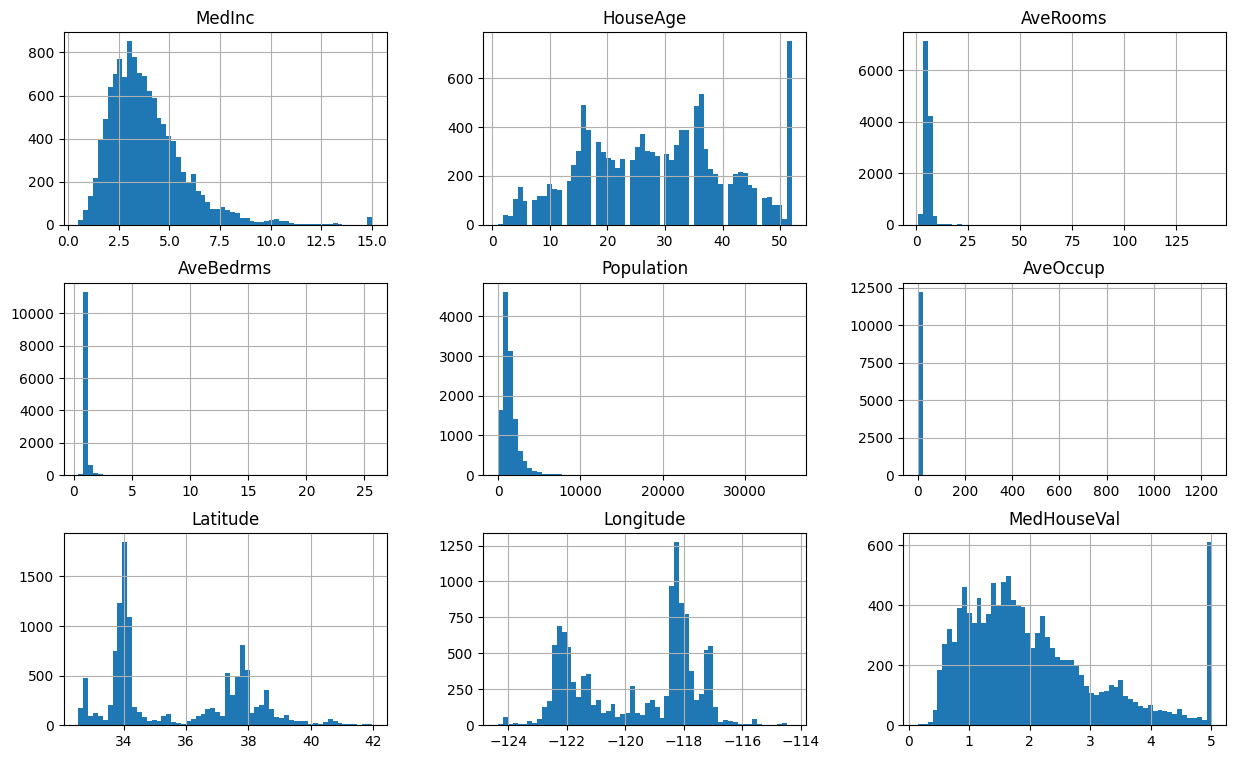

In [25]:
train_df.hist(bins=60, figsize=(15, 9))
plt.show()

##### 1.6.1.1. Дивні патерни та викиди (Odd Patterns & Outliers)

**Помітні з першого погляду:**

- **`HouseAge`** — розподіл загалом плавний, але з дивним піком на максимумі (52 роки): рівно **52.0** мають 750 рядків, тоді як сусідні значення (51, 50, 49...) — лише 20-115. Це не природний максимум, а **обрізання (capping)**: вік будинків у джерелі даних, судячи з усього, обмежили зверху 52 роками.
- **`MedHouseVal`** (наш таргет!) — той самий ефект: рівно **5.00001** мають 571 рядок, а наступне за величиною значення (5.00000) — лише 16 разів. Тобто ціни понад $500 тис. в оригінальних даних обрізані до цього рівня — реальна ціна могла бути й вищою, ми цього не знаємо.

**Менш очевидні — скошені розподіли:**

`Skewness` (асиметрія) показує, наскільки розподіл несиметричний: 0 — симетрично, чим більше значення — тим довший "хвіст" рідкісних великих значень праворуч (і тим менш надійне середнє як типове значення).

- 5 з 8 ознак мають помітно правосторонньо скошений розподіл: `MedInc` (≈1.6), `Population` (≈5.1), `AveRooms` (≈20.5), `AveBedrms` (≈24.3), `AveOccup` (≈78.3, той самий викид ~1243).
- `AveRooms`, `AveBedrms` і `Population` описують пов'язані речі (кімнати / спальні / населення в межах одного "блоку") — тому й мають схожу форму розподілу, зміщену в бік менших значень з довгим хвостом праворуч.
- На відміну від `HouseAge`/`MedHouseVal` (де пік — артефакт обрізання даних, який хіба що можна врахувати чи відкинути ці рядки), скошеність тут — природна властивість даних.

In [ ]:
from scipy.stats import skew

# HouseAge: скільки рядків мають рівно максимальне значення (ознака обрізання)
print("HouseAge — найбільші значення:")
print(train_df["HouseAge"].value_counts().sort_index(ascending=False).head(5))
print()

# MedHouseVal: те саме для таргету
print("MedHouseVal — найбільші значення:")
print(train_df["MedHouseVal"].value_counts().sort_index(ascending=False).head(5))
print()

# Skewness ≈ 0 — симетрично; чим більше — тим довший хвіст рідкісних великих значень
print("Skewness за колонками:")
for col in train_df.columns:
    if col == "MedHouseVal":
        continue
    print(f"{col}: {skew(train_df[col].dropna()):.2f}")

#### 1.6.2. Двовимірна кореляційна матриця (bivariate correlation)

Двовимірний аналіз (одразу дві ознаки) — вимірюємо лінійний зв'язок між кожною парою ознак. Дуже швидкий спосіб дізнатись дещо про датасет, але кореляція Пірсона показує **лише лінійну** схожість зв'язку.

На що звертати увагу:

- **Занадто висока або занадто низька кореляція з таргетом** — інколи привід відкинути ознаку
- **Багато пар з низькою кореляцією** — може означати нелінійний зв'язок, якого кореляція Пірсона просто не бачить
- **Висока кореляція між кількома ознаками** — вони можуть описувати схожі речі (мультиколінеарність)

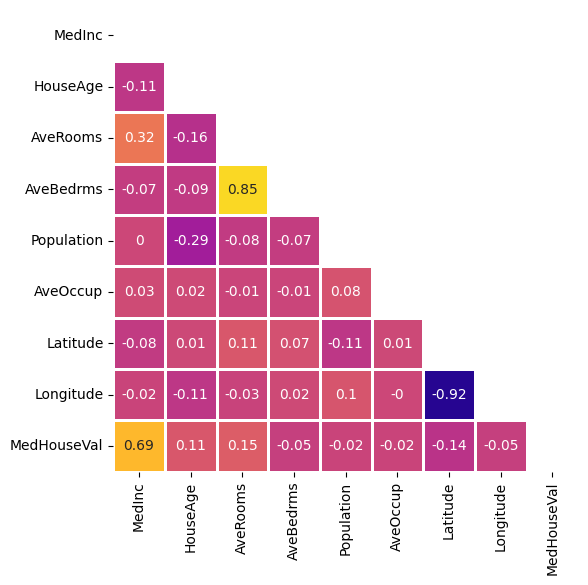

In [34]:
import seaborn as sns

''' Function to plot correlation of features '''
def corr_mat(df):
    corr = df.corr().round(2)
    f, ax = plt.subplots(figsize=(6, 6))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0,
                cmap="plasma", square=False, lw=2, annot=True, cbar=False)
    plt.show()

corr_mat(train_df)  # маскована (лише нижній трикутник) кореляційна матриця

##### 1.6.2.1. Аналіз кореляційної матриці

**Кореляція з таргетом.** `MedHouseVal` помітно корелює лише з однією ознакою — `MedInc` (0.69), решта — слабко (`AveRooms` 0.15, `Latitude` -0.14, `HouseAge` 0.11) або майже нуль (`Population` -0.03, `AveOccup` -0.02). Низька кореляція — не привід одразу видаляти ознаку: вона означає лише відсутність **лінійного** зв'язку, а не відсутність зв'язку взагалі. `AveOccup` — якраз такий випадок: величезна асиметрія (skewness ≈ 78) через екстремальний викид (1243) "ламає" лінійну кореляцію Пірсона, хоча в самій ознаці може лишатись корисна інформація.

**Кореляція між ознаками (мультиколінеарність).** Дві пари виділяються особливо сильно:

- `Latitude` і `Longitude`: **-0.91** — очікувано, географічні координати штату, витягнутого по діагоналі, природно пов'язані
- `AveRooms` і `AveBedrms`: **0.84** — логічно, чим більше кімнат у будинку, тим більше серед них спалень

Коли дві ознаки настільки сильно корелюють одна з одною, вони фактично несуть майже однакову інформацію. Для простих моделей це часто привід залишити лише одну ознаку з пари (або об'єднати їх) — інакше модель марно "ділить" вагу між дублюючими ознаками.

### 1.7. Обробка викидів (Outliers)

Ще один крок препроцесингу — розібратися з викидами, які ми вже частково помітили під час EDA (1.6.1.1).

#### 1.7.1. `HouseAge` і `MedInc`: капнуті ознаки — не викиди

У 1.6.1.1 ми помітили дивний пік на `HouseAge = 52`: 750 рядків із ~12200 мають рівно це значення. Це справді **обрізання (capping)** — вік будинків у джерелі даних штучно обмежили зверху 52 роками. Цей самий датасет (California Housing) добре відомий тим, що капнуто одразу декілька колонок: крім `HouseAge`, так само капнутий `MedInc` (дохід) — знизу і зверху.

Але **capping ознаки — це не привід її видаляти**. Обрізання спотворює лише саму ознаку (ми просто не знаємо, чи будинку рівно 52 роки, чи 80), але **не псує лейбл** (`MedHouseVal`) для цих рядків — ціна там усе ще правильна. Видаливши ці рядки, ми викинули б повністю валідні спостереження заради незначної втрати точності в одній ознаці. Стандартна практика для цього датасету — саме так і робити: капнуті *ознаки* лишають як є.

Куди серйозніша ситуація — коли капнутий **сам таргет**. Про це — далі.

In [ ]:
# Перевіряємо обидві "стелі"/"підлоги" — скільки рядків рівно на межі capping.
# Ці рядки НЕ видаляємо, лишаємо в train_df як є.

print("HouseAge == 52.0:", (train_df["HouseAge"] == 52.0).sum(), "рядків")
print("MedInc == 15.0001 (верхня межа):", (train_df["MedInc"] == 15.0001).sum(), "рядків")
print("MedInc == 0.4999 (нижня межа):", (train_df["MedInc"] == 0.4999).sum(), "рядків")

#### 1.7.2. `MedHouseVal`: капнутий таргет — це серйозніше

У 1.6.1.1 ми бачили: `MedHouseVal = 5.00001` мають 571 рядок. На відміну від `HouseAge`/`MedInc`, тут капнута не ознака, а **сам лейбл**: для цих будинків ми просто не знаємо реальну ціну — вона могла бути й вищою за $500 тис., але в даних записана однаково.

Це вже класична проблема (добре відома саме для цього датасету): модель, натренована на таких рядках, вчиться на неправильних відповідях у верхньому ціновому діапазоні. Типові варіанти дій:

- **Видалити ці рядки** (з train і test) — чесніше, але втрачаємо ~5% даних і модель взагалі не буде вміти оцінювати дорогі будинки
- **Залишити як є** — прийнявши, що модель НЕ буде добре передбачати ціни в районі $500k+, і оцінка на test у цьому діапазоні буде необ'єктивною
- **Зібрати справжні лейбли** для цих рядків — найкращий, але зазвичай нереалістичний варіант

Тут немає однозначно "правильної" відповіді — рішення залежить від того, наскільки для задачі важливий саме верхній ціновий сегмент. Поки що **не чіпаємо** ці рядки — повертаємось до цього рішення, якщо знадобиться.

#### 1.7.3. `AveOccup`, `AveRooms`, `AveBedrms`: схоже на помилки в даних

Ці три ознаки — середні значення (Ave = Average): загальна кількість (людей/кімнат/спалень) поділена на кількість домогосподарств у блоці. Кількість домогосподарств у даних немає напряму, але її можна прикинути як `Population / AveOccup`.

Подивимось на рядок з `AveOccup = 1243` (найбільший викид, який ми вже бачили): `Population ≈ 7460`. Тобто оцінка кількості домогосподарств — `7460 / 1243 ≈ 6`. Населення 7460 осіб на 6 домогосподарств — фізично неможливо. Найімовірніше пояснення: кількість домогосподарств у цьому блоці записана з помилкою (замість, скажімо, 600+ записали щось на кшталт 6) — і ця помилка "пробивається" одразу в `AveOccup`, `AveRooms` і `AveBedrms`, бо всі вони діляться на ту саму (хибну) кількість домогосподарств.

На відміну від `HouseAge`/`MedInc` (де причина — свідоме обрізання джерелом даних) і `MedHouseVal` (де причина — та сама причина, але для лейблу), тут причина — **помилка запису даних**. Це саме той випадок, коли видалення виправдане.

In [ ]:
# Оцінюємо кількість домогосподарств: Population / AveOccup.
# Дуже мала оцінка при великому Population — ознака помилки запису даних.
estimated_households = train_df["Population"] / train_df["AveOccup"]

suspicious = train_df[(estimated_households < 20) & (train_df["Population"] > 500)]
print(f"Підозрілих рядків (оцінка домогосподарств < 20, Population > 500): {len(suspicious)}")
suspicious[["Population", "AveOccup", "AveRooms", "AveBedrms"]]

#### 1.7.4. Які викиди видаляти, а які — ні

Не кожен викид варто видаляти — головне питання: **звідки він узявся**.

- **Обрізання (capping) ознаки** — `HouseAge`, `MedInc`. Спотворює лише саму ознаку, лейбл лишається правильним → **не видаляємо**.
- **Обрізання (capping) таргету** — `MedHouseVal`. Лейбл сам по собі неправильний для цих рядків → серйозніше питання, рішення залежить від задачі (1.7.2).
- **Помилка запису даних** — `AveOccup`/`AveRooms`/`AveBedrms` з неправдоподібно малою оціненою кількістю домогосподарств (1.7.3) → **видаляти виправдано**, ці значення не несуть корисної інформації про реальний світ.
- **Реальне, хоч і рідкісне спостереження** (напр. `Population` під 35 тисяч — це великий, але цілком можливий щільно заселений блок) → видаляти небезпечно: це природна варіативність даних, і модель, яка ніколи такого не бачила, може погано впоратись із подібним випадком у продакшені. Тут краще трансформація (логарифм), robust-масштабування, або просто залишити як є.
- Якщо не впевнені, звідки взявся викид — **не видаляйте одразу**: порівняйте якість моделі з ним і без нього, це надійніше за інтуїцію.

І ще одне правило: викиди чистимо **тільки в train**. `val` і `test` мають лишатись "як є", бо вони імітують реальні дані, з якими модель зіткнеться в проді — видаливши незручні приклади з test, оцінку зробимо нечесно оптимістичною.

### 1.8. Інженерія ознак (Feature Engineering)

Інженерія ознак — створення й зміна ознак так, щоб модель отримувала максимум релевантного сигналу з мінімумом дублювання. Це ітеративний процес: спробували комбінацію → перевірили кореляцію з таргетом → залишили або відкинули.

Ми вже знайшли дві пари ознак, які сильно корелюють між собою (1.6.2.1): `Latitude`/`Longitude` (-0.91) і `AveRooms`/`AveBedrms` (0.84). Спробуємо об'єднати кожну пару в щось корисніше.

#### 1.8.1. Географічна ознака: `diag_coord`

Каліфорнія витягнута по діагоналі (з північного заходу на південний схід), тому сума координат (`Latitude + Longitude`) — це проєкція положення вздовж цієї діагоналі, яка приблизно відображає віддаленість від узбережжя.

Формула детермінована (не статистика на кшталт медіани), тому застосовуємо її однаково до train, val і test — витоку даних тут немає.

In [ ]:
for d in (train_df, val_df, test_df):
    d["diag_coord"] = d["Latitude"] + d["Longitude"]

print("Кореляція з MedHouseVal:")
print("Latitude:   ", train_df["Latitude"].corr(train_df["MedHouseVal"]).round(3))
print("Longitude:  ", train_df["Longitude"].corr(train_df["MedHouseVal"]).round(3))
print("diag_coord: ", train_df["diag_coord"].corr(train_df["MedHouseVal"]).round(3))

#### 1.8.2. Співвідношення спалень до кімнат: `bedperroom`

`AveRooms` і `AveBedrms` сильно корелюють між собою (0.85) — ймовірно, частково несуть однакову інформацію. Спробуємо натомість частку: яка частка кімнат у будинку — спальні.

In [ ]:
for d in (train_df, val_df, test_df):
    d["bedperroom"] = d["AveBedrms"] / d["AveRooms"]

print("Кореляція з MedHouseVal:")
print("AveRooms:   ", train_df["AveRooms"].corr(train_df["MedHouseVal"]).round(3))
print("AveBedrms:  ", train_df["AveBedrms"].corr(train_df["MedHouseVal"]).round(3))
print("bedperroom: ", train_df["bedperroom"].corr(train_df["MedHouseVal"]).round(3))

#### 1.8.3. Прибираємо зайве

`diag_coord` корелює з таргетом набагато сильніше (-0.46), ніж `Latitude` (-0.14) чи `Longitude` (-0.05) окремо — і при цьому не дублює жодну з них напряму (кореляція з `Latitude` — 0.35, з `Longitude` — 0.07, обидві далекі від 1). Прибираємо обидві початкові координати, лишаємо тільки `diag_coord`.

`bedperroom` теж корелює з таргетом сильніше (-0.25), ніж `AveRooms` (0.15) чи `AveBedrms` (-0.05) окремо. Але, на відміну від координат, `bedperroom` не "поглинає" `AveRooms` повністю (кореляція між ними лише -0.42) — тож `AveRooms` лишаємо як окрему ознаку. `AveBedrms`, натомість, сама по собі майже не корелює з таргетом і сильно дублює `AveRooms` — її прибираємо.

In [ ]:
for d in (train_df, val_df, test_df):
    d.drop(columns=["Latitude", "Longitude", "AveBedrms"], inplace=True)

print("Колонки, що лишились:", list(train_df.columns))

---
## 2. Множинна лінійна регресія (Multiple Linear Regression)

Дані готові — час побудувати першу модель. Починаємо з найпростішого варіанта: **лінійної регресії з кількома ознаками** (множинна = кілька ознак одразу, на відміну від однієї `TikToks per Day → IQ` з попередньої лекції).

Це не просто вправа для розігріву — це **baseline**. Якщо пізніше складніша модель (нейромережа) не зможе побити просту лінійну регресію, це сигнал, що щось не так — або з даними, або з підбором архітектури. Тому лінійну регресію будуємо й оцінюємо **першою**, і лише потім переходимо до нейромережі.

### 2.1. Стандартизація ознак (Standardization)

**Термінологічна примітка.** "Нормалізація" і "стандартизація" — не синоніми, хоч їх часто вживають як взаємозамінні.

Тут ми робимо саме **стандартизацію**: приводимо кожну ознаку до середнього 0 і стандартного відхилення 1:

$$z = \frac{x - \mu}{\sigma}$$

де $\mu$ і $\sigma$ — середнє і стандартне відхилення, пораховані **тільки на train**. 

**Нормалізація** (у вузькому сенсі) — інша операція: стискає значення у фіксований діапазон, зазвичай $[0, 1]$:

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Навіщо це взагалі: градієнтні оптимізатори сходяться швидше й стабільніше, коли ознаки мають приблизно однаковий масштаб — інакше крок, який годиться для `MedInc` (0-15), буде або замалим, або завеликим для `Population` (сотні-тисячі).

**Альтернативи `StandardScaler`, які варто знати:**

- [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) — саме "нормалізація" у вузькому сенсі, стискає в $[0, 1]$; чутлива до викидів (один екстремум розтягує весь діапазон)
- [`RobustScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html) — використовує медіану та міжквартильний розмах (IQR) замість середнього й std, тому стійкіша до викидів
- [`MaxAbsScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) — ділить на максимальне абсолютне значення, зберігає розрідженість (корисно для sparse-даних)

Для лінійних моделей і нейромереж `StandardScaler` — стандартний вибір за замовчуванням, тому беремо його. Його API з `fit`/`transform` ([документація](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) якраз і змушує рахувати статистику лише один раз, на train — той самий принцип, що й у розділі про пропуски.

In [ ]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in train_df.columns if c != "MedHouseVal"]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])  # fit + transform тільки на train
X_val = scaler.transform(val_df[feature_cols])           # той самий scaler, лише transform
X_test = scaler.transform(test_df[feature_cols])

y_train = train_df["MedHouseVal"].values
y_val = val_df["MedHouseVal"].values
y_test = test_df["MedHouseVal"].values

print("Ознаки:", feature_cols)
print("Форма X_train:", X_train.shape)

### 2.2. Конвертуємо в тензори PyTorch

Той самий підхід, що й у лекції 2: numpy-масиви → `torch.tensor` → на потрібний `device`.

In [ ]:
def to_tensor(X, y):
    return (
        torch.tensor(X, dtype=torch.float32).to(device),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device),
    )

x_train_t, y_train_t = to_tensor(X_train, y_train)
x_val_t, y_val_t = to_tensor(X_val, y_val)
x_test_t, y_test_t = to_tensor(X_test, y_test)

### 2.3. Будуємо і тренуємо модель

Модель — [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html): на вхід `n_features` чисел, на виході одне число (передбачена ціна). Це і є вся "множинна лінійна регресія": `y = w1·x1 + w2·x2 + ... + b`.

Loss — [`MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) (середньоквадратична помилка, стандарт для регресії). Оптимізатор — класичний [`SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html): найпростіший варіант, оновлює ваги пропорційно до градієнта з фіксованим кроком (learning rate). Для нейромережі пізніше візьмемо складніший `Adam` — а для лінійної моделі й звичайного SGD цілком достатньо.

Заразом логуємо train/val loss через `SummaryWriter` — той самий TensorBoard з лекції 2, тепер уже на реальній задачі. Кожен запуск пишемо в окрему підпапку `RUNS_DIR`, щоб пізніше (3.8) накласти криву лінійної регресії й нейромережі одна на одну в одному вікні TensorBoard.

In [ ]:
from torch.utils.tensorboard import SummaryWriter

N_EPOCHS = 200

n_features = X_train.shape[1]
linear_model = torch.nn.Linear(in_features=n_features, out_features=1).to(device)
optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()
writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, "linear_regression"))

train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    linear_model.train()
    optimizer.zero_grad()
    y_pred = linear_model(x_train_t)
    loss = loss_fn(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    linear_model.eval()
    with torch.no_grad():
        val_loss = loss_fn(linear_model(x_val_t), y_val_t).item()
    val_losses.append(val_loss)

    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    if epoch % 40 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss:.4f}")

writer.close()

### 2.4. Крива навчання

Найшвидша діагностика проблем із моделлю:

- **train і val падають і сходяться близько** — модель вчиться нормально
- **train падає, а val росте (або застряг)** — overfitting: модель запам'ятовує train, а не узагальнює
- **обидва лишаються високими** — underfitting: моделі не вистачає складності, або погано підібрані гіперпараметри

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Крива навчання: лінійна регресія")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 2.5. Оцінюємо на test

Порівнюємо модель з бейзлайном — завжди прогнозувати середню ціну по train. Якщо модель не б'є такий примітивний бейзлайн, вона марна.

Метрики регресії ([документація sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)):

- **MSE** — середньоквадратична помилка (те, що оптимізували):
  $$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
- **RMSE** — корінь з MSE, в одиницях самого таргету — легше інтерпретувати:
  $$\text{RMSE} = \sqrt{\text{MSE}}$$
- **MAE** — середня абсолютна похибка, менш чутлива до викидів, ніж MSE:
  $$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$
- **R²** — частка дисперсії таргету, яку пояснює модель: 1.0 — ідеально, 0.0 — не краще за бейзлайн (середнє):
  $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_model.eval()
with torch.no_grad():
    y_test_pred = linear_model(x_test_t).cpu().numpy().flatten()

baseline_pred = np.full_like(y_test, y_train.mean())


def report(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:14s}  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")


report(y_test, baseline_pred, "Бейзлайн")
report(y_test, y_test_pred, "Лін. регресія")

### 2.6. Інтерпретуємо ваги

Ознаки стандартизовані (однаковий масштаб), тому абсолютне значення ваги напряму показує силу впливу ознаки на прогноз — без стандартизації порівнювати ваги було б некоректно (дохід і кількість кімнат мають різні одиниці й масштаб).

Заразом перевіримо, чи виправдала себе інженерія ознак з 1.8: чи `diag_coord`/`bedperroom` виявляться вагомими, чи навпаки, зайвими.

In [ ]:
weights = linear_model.weight.detach().cpu().numpy().flatten()
weight_df = pd.DataFrame({"feature": feature_cols, "weight": weights})
weight_df["abs_weight"] = weight_df["weight"].abs()
weight_df = weight_df.sort_values("abs_weight", ascending=False).drop(columns="abs_weight")

print(weight_df.to_string(index=False))

---
## 3. Нейронна мережа (MLP)

Лінійна регресія дала нам baseline. Тепер спробуємо побити його нейромережею — багатошаровим перцептроном (Multi-Layer Perceptron, MLP). Мета не "нейромережа заради нейромережі", а перевірити конкретну гіпотезу: чи є в даних **нелінійні** залежності, яких лінійна модель просто не могла побачити.

### 3.1. Навіщо взагалі нейромережа (нелінійність)

Здавалося б, можна просто скласти кілька `nn.Linear` шарів підряд і отримати "глибшу" модель. Але це не працює: добуток лінійних перетворень — це знову лінійне перетворення (добуток матриць — це матриця). Тобто 5 шарів `nn.Linear` підряд, без нічого між ними, математично еквівалентні одному-єдиному лінійному шару — жодної нової здатності моделювати ми не отримуємо.

Саме тому між шарами ставлять **функцію активації** — нелінійне перетворення. Це і є секрет нейромереж: чергування лінійних перетворень і нелінійних активацій дозволяє наблизити майже будь-яку функцію, включно з нелінійними залежностями.

Це не абстрактна теорія — ми вже бачили натяки на нелінійність у наших даних (1.6.2.1): `Population` і `AveOccup` мають майже нульову **лінійну** кореляцію з таргетом, але це не означає відсутність зв'язку взагалі — можливо, зв'язок є, просто не лінійний. Лінійна регресія такий зв'язок вловити не може в принципі; подивимось, чи зможе нейромережа.

### 3.2. Функції активації

Найпоширеніші варіанти:

- [**ReLU**](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) — $\text{ReLU}(x) = \max(0, x)$. Стандартний вибір для прихованих шарів: рахується миттєво, і на відміну від sigmoid/tanh не "затухає" на великих значеннях (менше проблем із зникаючим градієнтом при глибоких мережах).
- [**Sigmoid**](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) — стискає будь-яке число в $(0, 1)$. Історично використовувалась у прихованих шарах, зараз — здебільшого на виході мережі для задач бінарної класифікації (як ймовірність).
- [**Tanh**](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html) — те саме, що sigmoid, але діапазон $(-1, 1)$ і симетричний відносно нуля.

Для прихованих шарів у нашій моделі використовуємо ReLU — це поточний стандартний вибір за замовчуванням.

### 3.3. Архітектура

Два приховані шари з ReLU: `n_features → 64 → 32 → 1`. Вхід — ті самі стандартизовані ознаки, що й у лінійній регресії (`x_train_t`), жодного додаткового feature engineering.

Кількість шарів і нейронів у них (64, 32) — гіперпараметри, підібрані як розумна відправна точка, а не єдино правильне число. Саме такі рішення (скільки шарів, скільки нейронів, яка активація) і потрібно буде експериментально підбирати на власному датасеті.

In [ ]:
housing_nn = torch.nn.Sequential(
    torch.nn.Linear(n_features, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1),
).to(device)

print(housing_nn)
print("Кількість параметрів NN:      ", sum(p.numel() for p in housing_nn.parameters()))
print("Кількість параметрів лінійної:", sum(p.numel() for p in linear_model.parameters()))

### 3.4. Оптимізатор Adam

У лінійній регресії використали `SGD` — фіксований крок для всіх ваг одразу. [`Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) розумніший: підтримує окремий адаптивний крок для **кожної** ваги окремо, на основі "пам'яті" про попередні градієнти (моментум) і про те, наскільки вони були стабільними. На практиці це означає швидшу й стабільнішу збіжність, особливо для мереж із багатьма шарами й параметрами — тому Adam зазвичай і є вибором за замовчуванням для нейромереж.

Плата за це — на порядок менший learning rate, ніж у SGD (тут `0.01` проти `0.1`): адаптивні кроки Adam самі по собі "агресивніші", завеликий `lr` легко зіб'є навчання. Детальніше про інтуїцію різних оптимізаторів — [огляд Sebastian Ruder](https://www.ruder.io/optimizing-gradient-descent/).

### 3.5. Тренуємо модель

Та сама логіка циклу навчання, що й для лінійної регресії — тільки модель і оптимізатор інші. І так само логуємо в TensorBoard, в окрему підпапку `RUNS_DIR`.

In [ ]:
N_EPOCHS = 300

optimizer = torch.optim.Adam(housing_nn.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()
writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, "neural_network"))

nn_train_losses, nn_val_losses = [], []

for epoch in range(N_EPOCHS):
    housing_nn.train()
    optimizer.zero_grad()
    y_pred = housing_nn(x_train_t)
    loss = loss_fn(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    nn_train_losses.append(loss.item())

    housing_nn.eval()
    with torch.no_grad():
        val_loss = loss_fn(housing_nn(x_val_t), y_val_t).item()
    nn_val_losses.append(val_loss)

    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    if epoch % 40 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss:.4f}")

writer.close()

### 3.6. Крива навчання

Той самий чек-лист діагностики, що й раніше (2.4) — але зараз він важливіший: у NN у ~330 разів більше параметрів, ніж у лінійної моделі (перевірили в 3.3), а більша ємність моделі — це завжди більший ризик overfitting. Пильно дивимось, чи не почне val-крива рости, поки train падає.

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(nn_train_losses, label="train")
plt.plot(nn_val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Крива навчання: нейромережа")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 3.7. Порівнюємо з лінійною регресією

Ті самі метрики (2.5), тепер для всіх трьох варіантів разом: бейзлайн, лінійна регресія, нейромережа.

In [ ]:
housing_nn.eval()
with torch.no_grad():
    y_test_pred_nn = housing_nn(x_test_t).cpu().numpy().flatten()

report(y_test, baseline_pred, "Бейзлайн")
report(y_test, y_test_pred, "Лін. регресія")
report(y_test, y_test_pred_nn, "Нейромережа")

### 3.8. Переглядаємо в TensorBoard

Обидва прогони (лінійна регресія й нейромережа) уже залоговані в `RUNS_DIR`, кожен у своїй підпапці. TensorBoard автоматично покаже їх як окремі "run"-и на одному графіку — саме так найзручніше порівнювати криві навчання різних моделей візуально, а не по одному matplotlib-графіку на модель (2.4, 3.6).

In [ ]:
%load_ext tensorboard
%tensorboard --logdir {RUNS_DIR}

### 3.9. Підсумок: чи виправдала себе нейромережа?

На наших даних нейромережа помітно побила лінійну регресію (R² ≈ 0.74 проти ≈ 0.60) — гіпотеза з 3.1 підтвердилась: у даних справді була нелінійна складова, якої лінійна модель не бачила. Крива навчання (3.6, або те саме в TensorBoard — 3.8) при цьому виглядає здоровою: train і val ідуть поруч, ознак overfitting немає, а обидві криві на 300-й епосі ще повільно спадають — тобто моделі, ймовірно, є куди рости далі (більше епох, інша архітектура, підбір learning rate).

Це не завжди так: нейромережа перемагає не автоматично, а тому, що в конкретно цих даних дійсно є нелінійний сигнал, і в моделі достатньо ємності й даних, щоб його вивчити, не перевчившись. На інших даних (де залежність справді лінійна, або даних замало для складної моделі) простіша лінійна регресія цілком може виявитись кращим вибором — саме тому й важливо було спершу побудувати бейзлайн (2), а не одразу хапатись за нейромережу.

Саме цей цикл — **побудувати простий бейзлайн → спробувати складнішу модель → чесно порівняти на test → поекспериментувати з архітектурою/гіперпараметрами (стежачи за кривими в TensorBoard)** — і є тим, що варто повторити на власному датасеті.